In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parents[0]  # adjust if running in notebook
sys.path.append(str(repo_root / "vis" / "python"))

import bin_convert_new as bc

In [3]:
N = 49
out_dict = bc.read_binary_as_athdf(f"bin/Conv.hydro_w.{N:05d}.bin")
print(out_dict.keys())

FileNotFoundError: [Errno 2] No such file or directory: 'bin/Conv.hydro_w.00049.bin'

(array([2.8900e+02, 3.1810e+03, 1.1398e+04, 2.1257e+04, 2.8547e+04,
        3.9772e+04, 4.8967e+04, 5.2581e+04, 5.8242e+04, 5.8988e+04,
        5.5785e+04, 5.2127e+04, 5.3831e+04, 5.0106e+04, 5.0877e+04,
        5.3202e+04, 5.9450e+04, 6.4043e+04, 6.3207e+04, 5.8375e+04,
        5.5977e+04, 5.6818e+04, 5.5124e+04, 5.2624e+04, 5.9819e+04,
        6.4756e+04, 6.3213e+04, 5.9533e+04, 5.4904e+04, 5.3027e+04,
        5.1173e+04, 5.0711e+04, 5.1150e+04, 4.8940e+04, 4.7025e+04,
        4.4678e+04, 4.5845e+04, 4.6904e+04, 4.6743e+04, 4.1563e+04,
        3.5416e+04, 3.1702e+04, 2.2434e+04, 1.4892e+04, 6.7830e+03,
        1.4470e+03, 4.0400e+02, 1.2000e+02, 3.7000e+01, 1.3000e+01]),
 array([-0.0396061 , -0.0388406 , -0.0380751 , -0.0373096 , -0.0365441 ,
        -0.0357786 , -0.03501311, -0.03424761, -0.03348211, -0.03271661,
        -0.03195111, -0.03118562, -0.03042012, -0.02965462, -0.02888912,
        -0.02812362, -0.02735812, -0.02659263, -0.02582713, -0.02506163,
        -0.02429613, -0.02

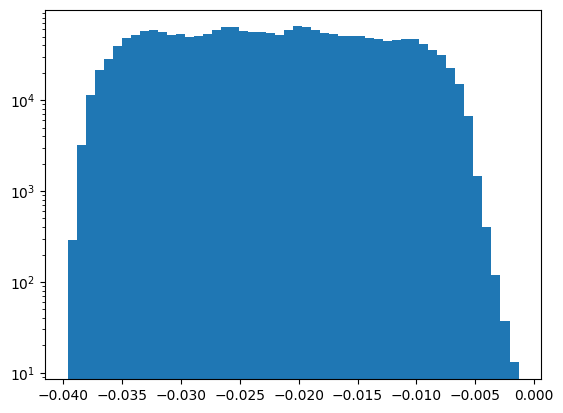

In [ ]:
# plt.hist(out_dict["dens"].flatten(), bins=50, log=True)
plt.hist(np.log10(out_dict["dens"]).flatten(), bins=50, log=True)

In [3]:
gamma_minus_1 = 5.0 / 3.0 - 1.0


def compute_temperature(out_dict):
    KE = (
        0.5
        * out_dict["dens"]
        * (out_dict["velx"] ** 2 + out_dict["vely"] ** 2 + out_dict["velz"] ** 2)
    )
    TE = out_dict["eint"] - KE

    T = (TE * gamma_minus_1) / out_dict["dens"]

    return T

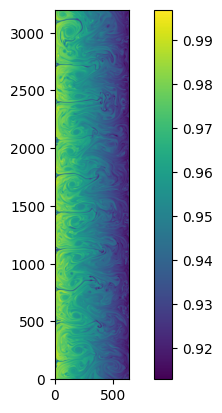

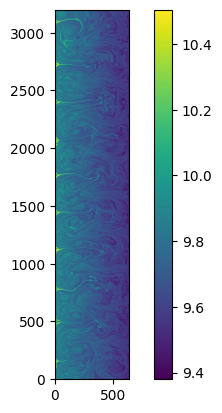

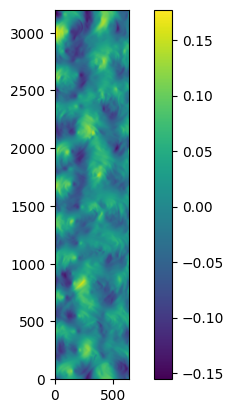

In [6]:
plt.figure()
plt.imshow(out_dict["dens"][0, :, :], origin="lower")
aspect = "equal"
plt.colorbar()

plt.figure()
plt.imshow(compute_temperature(out_dict)[0, :, :], origin="lower")
aspect = "equal"
plt.colorbar()

plt.figure()
plt.imshow(out_dict["vely"][0, :, :], origin="lower")
aspect = "equal"
plt.colorbar()

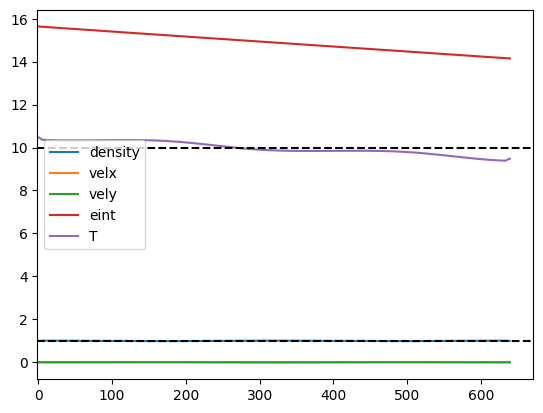

In [18]:
plt.plot(out_dict["dens"][0, 0, :], label="density")
plt.plot(out_dict["velx"][0, 0, :], label="velx")
plt.plot(out_dict["vely"][0, 0, :], label="vely")
plt.plot(out_dict["eint"][0, 0, :], label="eint")
plt.plot(compute_temperature(out_dict)[0, 0, :], label="T")

plt.axhline(1.0, color="k", ls="--")
plt.axhline(10.0, color="k", ls="--")

plt.xlim(-1, None)
plt.legend()

In [5]:
import cmasher as cm

for i in range(0, 200):
    print(f"Processing frame {i}")

    fig = plt.figure(figsize=(16, 3))
    out_dict = bc.read_binary_as_athdf(f"bin/Conv.hydro_w.{i:05d}.bin")

    arr_shape = out_dict["dens"].shape[1:]
    L_mul = int(arr_shape[0] / arr_shape[1])

    x_arr = np.linspace(0, 1, arr_shape[1] + 1)
    y_arr = np.linspace(0, L_mul, arr_shape[0] + 1)

    X, Y = np.meshgrid(y_arr, x_arr)

    plt.pcolormesh(
        X,
        Y,
        compute_temperature(out_dict)[0, :, :].T,
        # (out_dict["s_00"] / out_dict["dens"])[0, :, :],
        vmin=9.5,
        vmax=10.5,
        cmap=cm.bubblegum,
        # cmap=cm.redshift,
        shading="auto",
    )
    plt.colorbar()
    fig.savefig(f"bin/save/temp/temp_{i:05d}.png", dpi=600)
    plt.close(fig)

Processing frame 0
Processing frame 1
Processing frame 2
Processing frame 3
Processing frame 4
Processing frame 5
Processing frame 6
Processing frame 7
Processing frame 8
Processing frame 9
Processing frame 10
Processing frame 11
Processing frame 12
Processing frame 13


: 